# NB07 — What-If Clinical Simulator

**Purpose**: Interactive scenario engine — ingest hypothetical inputs (food, medications,
dialysate composition, dialysis variables, daily activities) and predict clinical outcomes
using the trained ML models from NB04 + S07.

**Patient**: Patient-001 | Male | Age 51 | ESRD on Home Hemodialysis

## Architecture

```
User Inputs ──→ Feature Builder ──→ Risk Models (12) ──→ Predicted Outcomes
     │                │                                         │
     │                ├── HEBCS Pathways ──→ Wellness Score      │
     │                └── Lab Trajectories ──→ Next-Day Labs     │
     │                                                          │
     └── (Parallel MATLAB/Simulink: S08_whatif_simulink.m) ─────┘
```

### Input Categories
| Category | Example Variables |
|----------|------------------|
| Nutrition | Food items, calories, protein, sodium, potassium, phosphorus |
| Medications | Calcium carbonate, Calcitriol, EPO, Iron, Heparin |
| Dialysis Rx | Blood flow rate, dialysate rate, bath Ca/K/Na, session duration |
| Dialysis Vitals | Pre/post weight, pre/post BP, UF goal |
| Activity | Session count, active days, rest streak |

### Predicted Outcomes (12 targets)
| Target | Type | Model |
|--------|------|-------|
| Holistic Score | Regression | GradientBoosting (R²=0.81) |
| Hypotension risk | Classification | Risk model |
| Anemia risk | Classification | Risk model |
| Hyperkalemia risk | Classification | Risk model |
| Hypokalemia risk | Classification | Risk model |
| Metabolic acidosis | Classification | Risk model |
| Iron deficiency | Classification | Risk model |
| Hyperparathyroid | Classification | Risk model |
| Hypocalcemia | Classification | Risk model |
| GI distress | Classification | Risk model |
| Malnutrition | Classification | Risk model |
| Poor health | Classification | Risk model |

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 1: Imports & Load All Models + Historical Data
# ═══════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import joblib
import json
import warnings
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
MODELS_DIR   = PROJECT_ROOT / 'models'
DATA_DIR     = PROJECT_ROOT / 'data'
PROCESSED    = DATA_DIR / 'processed'
FEATURES_DIR = DATA_DIR / 'features'

# ── Load trained models ──
print('Loading models...')
holistic_model = joblib.load(MODELS_DIR / 'holistic_health_model.joblib')
FEATURE_NAMES = list(holistic_model['pipeline'].feature_names_in_)
print(f'  Holistic model: {len(FEATURE_NAMES)} features, R²={holistic_model["metrics"]["R²"]:.3f}')

RISK_MODELS = {}
risk_names = ['anemia', 'gi_distress', 'hyperkalemia', 'hyperparathyroid',
              'hypocalcemia', 'hypokalemia', 'intradialytic_hypotension',
              'iron_deficiency', 'malnutrition', 'metabolic_acidosis', 'poor_health']
for rn in risk_names:
    try:
        RISK_MODELS[rn] = joblib.load(MODELS_DIR / f'risk_{rn}_model.joblib')
        print(f'  risk_{rn}: loaded')
    except Exception as e:
        print(f'  risk_{rn}: SKIP ({e})')

# ── Load pathway definitions ──
with open(MODELS_DIR / 'HEBCS_pathway_definitions.json') as f:
    PATHWAY_DEFS = json.load(f)
print(f'  HEBCS pathways: {list(PATHWAY_DEFS.keys())}')

# ── Load historical data for baseline distributions ──
print('\nLoading historical data...')
df_features = pd.read_csv(FEATURES_DIR / 'health_features.csv', parse_dates=['date'], index_col='date')
df_scores   = pd.read_csv(FEATURES_DIR / 'health_scores.csv', parse_dates=['date'], index_col='date')
df_nutrition = pd.read_csv(PROCESSED / 'unified_nutrition.csv', low_memory=False)
df_nutrition['date'] = pd.to_datetime(df_nutrition['date'], errors='coerce')
df_sessions = pd.read_csv(PROCESSED / 'dialysis_sessions.csv', low_memory=False)
df_sessions['session_date'] = pd.to_datetime(df_sessions['session_date'], errors='coerce')
df_labs = pd.read_csv(PROCESSED / 'unified_labs.csv', low_memory=False)
df_labs['date'] = pd.to_datetime(df_labs['date'], errors='coerce')
df_wellness = pd.read_csv(FEATURES_DIR / 'HEBCS_wellness_daily.csv', index_col=0, parse_dates=True)

print(f'  Features: {df_features.shape}')
print(f'  Scores: {df_scores.shape}')
print(f'  Nutrition rows: {len(df_nutrition)}')
print(f'  Dialysis sessions: {len(df_sessions)}')
print(f'  Lab results: {len(df_labs)}')
print(f'  Wellness days: {len(df_wellness)}')

# ── Historical baselines (medians) ──
BASELINE = df_features[FEATURE_NAMES].median().to_dict()
print(f'\nBaseline feature vector computed (median of {len(df_features)} days)')

Loading models...
  Holistic model: 284 features, R²=0.808
  risk_anemia: loaded
  risk_gi_distress: loaded
  risk_hyperkalemia: loaded
  risk_hyperparathyroid: loaded
  risk_hypocalcemia: loaded
  risk_hypokalemia: loaded
  risk_intradialytic_hypotension: loaded
  risk_iron_deficiency: loaded
  risk_malnutrition: loaded
  risk_metabolic_acidosis: loaded
  risk_poor_health: loaded
  HEBCS pathways: ['Metabolic', 'Digestive', 'Neurological', 'Hemolytical', 'Endocrinology', 'Bone_Formation', 'Immunological']

Loading historical data...
  Features: (3584, 347)
  Scores: (3584, 8)
  Nutrition rows: 4088
  Dialysis sessions: 1797
  Lab results: 9660
  Wellness days: 3584

Baseline feature vector computed (median of 3584 days)


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 2: What-If Engine — Core Prediction Functions
# ═══════════════════════════════════════════════════════════

def build_feature_vector(scenario: dict, baseline: dict = None) -> pd.DataFrame:
    """
    Build a 284-feature vector from user scenario inputs.
    Unmapped features fall back to baseline (historical median).
    
    scenario keys can be:
      - Nutrition: 'calories', 'protein', 'carbs', 'fat', 'fiber', 'sugar',
                   'sodium', 'potassium', 'calcium', 'iron', 'phosphorus'
      - Dialysis:  'pre_weight', 'post_weight', 'blood_flow', 'dialysate_rate',
                   'bath_ca', 'bath_k', 'bath_na', 'session_duration_min',
                   'pre_bp_sys', 'pre_bp_dia', 'uf_goal'
      - Meds:      'calcium_carbonate_doses', 'calcitriol_doses', 'epo_doses',
                   'iron_doses', 'heparin_doses'
      - Activity:  'sessions_7d', 'active_days_7d', 'rest_streak'
    """
    if baseline is None:
        baseline = BASELINE
    
    vec = baseline.copy()
    
    # ── Map scenario inputs → model features ──
    NUTRITION_MAP = {
        'calories': 'nutr_calories', 'protein': 'nutr_protein_g',
        'carbs': 'nutr_carbs_g', 'fat': 'nutr_fat_g',
        'fiber': 'nutr_fiber_g', 'sugar': 'nutr_sugar_g',
        'sodium': 'nutr_sodium_mg', 'potassium': 'nutr_potassium_mg',
        'calcium': 'nutr_calcium_mg', 'iron': 'nutr_iron_mg',
        'phosphorus': 'nutr_phosphorus_mg',
        'cholesterol': 'nutr_cholesterol_mg',
        'vitamin_d': 'nutr_vitamin_d_mcg', 'vitamin_b12': 'nutr_vitamin_b12_mcg',
        'folic_acid': 'nutr_folic_acid_mcg',
    }
    
    DIALYSIS_MAP = {
        'pre_weight': 'dial_pre_weight', 'post_weight': 'dial_post_weight',
        'blood_flow': 'dial_avg_blood_flow', 'dialysate_rate': 'dial_avg_dialysate_rate',
        'bath_ca': 'dial_bath_ca', 'bath_k': 'dial_bath_k', 'bath_na': 'dial_bath_na',
        'session_duration_min': 'dial_total_time_min',
        'pre_bp_sys': 'dial_pre_bp_sys', 'pre_bp_dia': 'dial_pre_bp_dia',
        'post_bp_sys': 'dial_post_bp_sys', 'post_bp_dia': 'dial_post_bp_dia',
        'uf_goal': 'dial_uf_total',
        'ktv': 'dial_ktv_actual',
    }
    
    MED_MAP = {
        'calcium_carbonate_doses': 'med_calcium_carbonate_doses',
        'calcitriol_doses': 'med_calcitriol_doses',
        'epo_doses': 'med_epo_doses',
        'iron_doses': 'med_iron_doses',
        'heparin_doses': 'med_heparin_doses',
    }
    
    ACTIVITY_MAP = {
        'sessions_7d': 'activity_dial_sessions_7d',
        'active_days_7d': 'activity_active_days_7d',
        'rest_streak': 'activity_rest_days_streak',
    }
    
    ALL_MAPS = {**NUTRITION_MAP, **DIALYSIS_MAP, **MED_MAP, **ACTIVITY_MAP}
    
    mapped_count = 0
    for user_key, value in scenario.items():
        if user_key in ALL_MAPS:
            feat_name = ALL_MAPS[user_key]
            if feat_name in vec:
                vec[feat_name] = value
                mapped_count += 1
    
    # Derived features
    if 'pre_weight' in scenario and 'post_weight' in scenario:
        wl = scenario['pre_weight'] - scenario['post_weight']
        if 'dial_weight_loss_kg' in vec:
            vec['dial_weight_loss_kg'] = wl
    
    if 'pre_bp_sys' in scenario and 'pre_bp_dia' in scenario:
        mmap = scenario['pre_bp_dia'] + (scenario['pre_bp_sys'] - scenario['pre_bp_dia']) / 3
        if 'dial_pre_map' in vec:
            vec['dial_pre_map'] = mmap
    
    if 'calories' in scenario:
        vec['dial_had_session'] = 1 if any(k in scenario for k in DIALYSIS_MAP) else vec.get('dial_had_session', 0)
    
    row = pd.DataFrame([vec])[FEATURE_NAMES]
    return row


def predict_whatif(scenario: dict, verbose: bool = True) -> dict:
    """
    Run all models on a scenario and return predicted outcomes.
    """
    X = build_feature_vector(scenario)
    results = {}
    
    # Holistic health score
    pipeline = holistic_model['pipeline']
    score = pipeline.predict(X)[0]
    results['holistic_score'] = np.clip(score, 0, 100)
    
    # Risk predictions
    for risk_name, model_pkg in RISK_MODELS.items():
        try:
            pipe = model_pkg['pipeline']
            prob = pipe.predict_proba(X)[0]
            risk_prob = prob[1] if len(prob) > 1 else prob[0]
            results[f'risk_{risk_name}'] = risk_prob
        except Exception:
            try:
                pred = pipe.predict(X)[0]
                results[f'risk_{risk_name}'] = float(pred)
            except:
                results[f'risk_{risk_name}'] = np.nan
    
    if verbose:
        print(f"\n{'═'*60}")
        print(f"  WHAT-IF PREDICTION RESULTS")
        print(f"{'═'*60}")
        print(f"\n  Holistic Health Score: {results['holistic_score']:.1f} / 100")
        print(f"\n  Risk Probabilities:")
        for k, v in sorted(results.items()):
            if k.startswith('risk_') and not np.isnan(v):
                name = k.replace('risk_', '').replace('_', ' ').title()
                bar = '█' * int(v * 30) + '░' * (30 - int(v * 30))
                flag = ' ⚠️' if v > 0.5 else ' ✅' if v < 0.2 else ''
                print(f"    {name:<30} {bar} {v:.1%}{flag}")
    
    return results


def compare_scenarios(scenarios: dict, labels: list = None) -> pd.DataFrame:
    """
    Run multiple scenarios side-by-side.
    scenarios: dict of {name: scenario_dict}
    """
    all_results = {}
    for name, sc in scenarios.items():
        all_results[name] = predict_whatif(sc, verbose=False)
    
    df = pd.DataFrame(all_results).T
    df.index.name = 'Scenario'
    return df


print('What-If engine ready.')
print(f'  {len(FEATURE_NAMES)} features, {len(RISK_MODELS)} risk models + holistic score')
print(f'  Baseline = median of {len(df_features)} historical days')

What-If engine ready.
  284 features, 11 risk models + holistic score
  Baseline = median of 3584 historical days


---
## Part 1: Single-Scenario What-If

Modify any inputs below and rerun to see predicted outcomes.

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 3: Example — Single Scenario Prediction
# ═══════════════════════════════════════════════════════════

# 🍽️  MODIFY THESE INPUTS to simulate a "what if" day:
scenario_today = {
    # ── Nutrition ──
    'calories': 2200,           # kcal (target: 1800-2500)
    'protein': 65,              # grams (target: 50-70g)
    'sodium': 1800,             # mg (target: <2000)
    'potassium': 1500,          # mg (target: <2000 for dialysis)
    'phosphorus': 700,          # mg (target: <800)
    'calcium': 600,             # mg
    'iron': 8,                  # mg
    'carbs': 280,               # g
    'fat': 70,                  # g
    'fiber': 20,                # g
    'sugar': 50,                # g
    
    # ── Dialysis Prescription ──
    'pre_weight': 55.2,         # kg
    'post_weight': 53.0,        # kg (UF = 2.2 kg)
    'blood_flow': 400,          # mL/min
    'dialysate_rate': 500,      # mL/min
    'bath_ca': 2.5,             # mEq/L
    'bath_k': 2.0,              # mEq/L
    'bath_na': 140,             # mEq/L
    'session_duration_min': 240, # 4 hours
    'pre_bp_sys': 140,          # mmHg
    'pre_bp_dia': 85,           # mmHg
    'ktv': 1.4,                 # Kt/V target
    
    # ── Medications ──
    'calcium_carbonate_doses': 3,
    'calcitriol_doses': 1,
    'epo_doses': 0,
    'iron_doses': 0,
    'heparin_doses': 1,
    
    # ── Activity ──
    'sessions_7d': 4,           # dialysis sessions in past 7 days
    'active_days_7d': 5,
    'rest_streak': 1,
}

results = predict_whatif(scenario_today)


════════════════════════════════════════════════════════════
  WHAT-IF PREDICTION RESULTS
════════════════════════════════════════════════════════════

  Holistic Health Score: 58.1 / 100

  Risk Probabilities:
    Anemia                         █████████████████████████████░ 97.7% ⚠️
    Gi Distress                    ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 8.7% ✅
    Hyperkalemia                   ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 1.0% ✅
    Hyperparathyroid               █████████████████████████████░ 97.0% ⚠️
    Hypocalcemia                   ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.0% ✅
    Hypokalemia                    ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 2.4% ✅
    Intradialytic Hypotension      █████░░░░░░░░░░░░░░░░░░░░░░░░░ 17.2% ✅
    Iron Deficiency                ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 3.0% ✅
    Malnutrition                   ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.0% ✅
    Metabolic Acidosis             ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.5% ✅
    Poor Health                    ░░░░░░░░░░░░░░░░░░

---
## Part 2: Multi-Scenario Comparison

Compare different dietary / treatment strategies side-by-side.

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 4: Compare Scenarios — Dietary Impact
# ═══════════════════════════════════════════════════════════

scenarios = {
    'Optimal Diet': {
        'calories': 2100, 'protein': 60, 'sodium': 1500,
        'potassium': 1200, 'phosphorus': 600, 'calcium': 800,
        'iron': 10, 'fiber': 25, 'sugar': 30,
        'pre_weight': 54.5, 'post_weight': 53.0,
        'blood_flow': 400, 'bath_k': 2.0, 'bath_ca': 2.5,
        'calcium_carbonate_doses': 3, 'calcitriol_doses': 1,
    },
    'High Sodium Day': {
        'calories': 2400, 'protein': 55, 'sodium': 3500,  # ⚠️ high
        'potassium': 1800, 'phosphorus': 900, 'calcium': 400,
        'iron': 5, 'fiber': 12, 'sugar': 80,
        'pre_weight': 56.0, 'post_weight': 53.0,  # big UF
        'blood_flow': 400, 'bath_k': 2.0, 'bath_ca': 2.5,
        'calcium_carbonate_doses': 2, 'calcitriol_doses': 1,
    },
    'High K+ (Risky)': {
        'calories': 2000, 'protein': 70, 'sodium': 2000,
        'potassium': 3500,  # ⚠️ dangerous
        'phosphorus': 1000, 'calcium': 500,
        'iron': 6, 'fiber': 15, 'sugar': 60,
        'pre_weight': 55.0, 'post_weight': 53.5,
        'blood_flow': 350, 'bath_k': 3.0, 'bath_ca': 2.5,
        'calcium_carbonate_doses': 1, 'calcitriol_doses': 0,
    },
    'Low Protein (Risk)': {
        'calories': 1500, 'protein': 25,  # ⚠️ low
        'sodium': 1800, 'potassium': 1000, 'phosphorus': 400,
        'calcium': 300, 'iron': 4, 'fiber': 10, 'sugar': 70,
        'pre_weight': 54.0, 'post_weight': 53.0,
        'blood_flow': 400, 'bath_k': 2.0, 'bath_ca': 2.5,
        'calcium_carbonate_doses': 3, 'calcitriol_doses': 1,
    },
    'Missed Session': {
        'calories': 2200, 'protein': 60, 'sodium': 2000,
        'potassium': 2000, 'phosphorus': 800, 'calcium': 600,
        'iron': 8, 'fiber': 18, 'sugar': 45,
        'sessions_7d': 2,  # ⚠️ only 2 sessions
        'rest_streak': 3,
    },
}

comp_df = compare_scenarios(scenarios)
print("\n" + "═" * 90)
print("  SCENARIO COMPARISON")
print("═" * 90)
print(f"\n{'Scenario':<25} {'Health':>7} {'Hypotn':>7} {'Anemia':>7} {'HyperK':>7} "
      f"{'Acidosis':>8} {'GI':>7} {'Malnutr':>8}")
print("─" * 90)
for sc_name, row in comp_df.iterrows():
    print(f"{sc_name:<25} {row['holistic_score']:>6.1f} "
          f"{row.get('risk_intradialytic_hypotension', 0):>6.1%} "
          f"{row.get('risk_anemia', 0):>6.1%} "
          f"{row.get('risk_hyperkalemia', 0):>6.1%} "
          f"{row.get('risk_metabolic_acidosis', 0):>7.1%} "
          f"{row.get('risk_gi_distress', 0):>6.1%} "
          f"{row.get('risk_malnutrition', 0):>7.1%}")


══════════════════════════════════════════════════════════════════════════════════════════
  SCENARIO COMPARISON
══════════════════════════════════════════════════════════════════════════════════════════

Scenario                   Health  Hypotn  Anemia  HyperK Acidosis      GI  Malnutr
──────────────────────────────────────────────────────────────────────────────────────────
Optimal Diet                54.7   7.3%  97.7%   0.5%    0.5%   9.6%    0.0%
High Sodium Day             54.7   8.0%  97.7%   0.5%    0.0%   9.6%    0.0%
High K+ (Risky)             54.8   7.3%  98.2%   0.5%    0.0%   9.6%    0.0%
Low Protein (Risk)          53.3   6.1%  97.7%   0.5%    0.5%   9.6%    0.0%
Missed Session              51.9   4.2%  98.2%   0.5%    0.0%   7.5%    0.0%


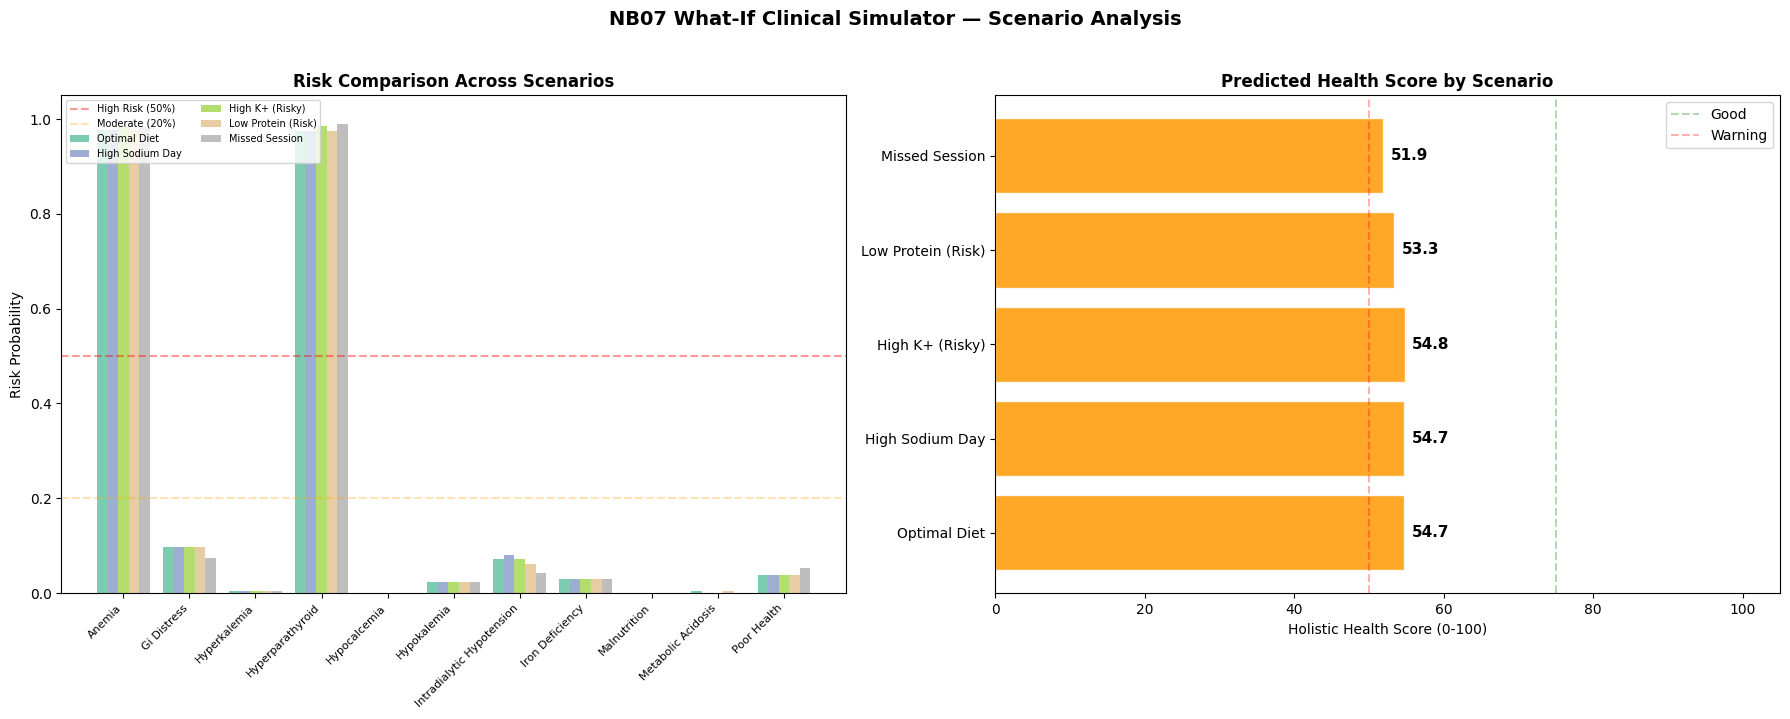

Saved: whatif_scenario_comparison.png


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 5: Visualization — Scenario Comparison Radar + Bar
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Grouped bar chart of risk probabilities ──
ax = axes[0]
risk_cols = [c for c in comp_df.columns if c.startswith('risk_')]
risk_labels = [c.replace('risk_', '').replace('_', ' ').title() for c in risk_cols]

n_scenarios = len(comp_df)
n_risks = len(risk_cols)
x = np.arange(n_risks)
width = 0.8 / n_scenarios
colors = plt.cm.Set2(np.linspace(0, 1, n_scenarios))

for i, (sc_name, row) in enumerate(comp_df.iterrows()):
    vals = [row[c] for c in risk_cols]
    ax.bar(x + i * width, vals, width, label=sc_name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * (n_scenarios - 1) / 2)
ax.set_xticklabels(risk_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Risk Probability')
ax.set_title('Risk Comparison Across Scenarios', fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='High Risk (50%)')
ax.axhline(y=0.2, color='orange', linestyle='--', alpha=0.3, label='Moderate (20%)')
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.set_ylim(0, 1.05)

# ── Right: Holistic score comparison ──
ax = axes[1]
sc_names = list(comp_df.index)
scores = comp_df['holistic_score'].values
bar_colors = ['#4CAF50' if s >= 75 else '#FF9800' if s >= 50 else '#F44336' for s in scores]
bars = ax.barh(sc_names, scores, color=bar_colors, alpha=0.85, edgecolor='white')

# Add score labels
for bar, sc in zip(bars, scores):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{sc:.1f}', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Holistic Health Score (0-100)')
ax.set_title('Predicted Health Score by Scenario', fontweight='bold')
ax.axvline(x=75, color='green', linestyle='--', alpha=0.3, label='Good')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.3, label='Warning')
ax.legend()
ax.set_xlim(0, 105)

plt.suptitle('NB07 What-If Clinical Simulator — Scenario Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'whatif_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: whatif_scenario_comparison.png')

---
## Part 3: Sensitivity Analysis — One Variable at a Time

Sweep each input variable across its clinical range to see nonlinear effects.

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 6: Sensitivity Sweeps — Key Clinical Variables
# ═══════════════════════════════════════════════════════════

SWEEP_VARS = {
    # (variable_name, min, max, n_steps, unit, ESRD_range_low, ESRD_range_high)
    'potassium':          (500,  5000, 50, 'mg',    1000, 2000),
    'sodium':             (500,  5000, 50, 'mg',    1000, 2000),
    'phosphorus':         (200,  2000, 50, 'mg',    400,  800),
    'protein':            (10,   120,  50, 'g',     50,   70),
    'calories':           (800,  4000, 50, 'kcal',  1800, 2500),
    'blood_flow':         (200,  500,  50, 'mL/min',350,  450),
    'bath_k':             (1.0,  4.0,  50, 'mEq/L', 1.5,  2.5),
    'pre_bp_sys':         (90,   200,  50, 'mmHg',  120,  150),
    'session_duration_min':(120, 360,  50, 'min',   180,  270),
}

# Run sweeps
sweep_results = {}
for var_name, (vmin, vmax, nsteps, unit, rlo, rhi) in SWEEP_VARS.items():
    values = np.linspace(vmin, vmax, nsteps)
    scores = []
    risks_hyper_k = []
    risks_hypo = []
    for v in values:
        sc = {var_name: v}
        r = predict_whatif(sc, verbose=False)
        scores.append(r['holistic_score'])
        risks_hyper_k.append(r.get('risk_hyperkalemia', 0))
        risks_hypo.append(r.get('risk_intradialytic_hypotension', 0))
    sweep_results[var_name] = {
        'values': values, 'scores': scores,
        'risk_hyperkalemia': risks_hyper_k,
        'risk_hypotension': risks_hypo,
        'unit': unit, 'range': (rlo, rhi)
    }

print(f'Completed {len(sweep_results)} sensitivity sweeps × {nsteps} steps each')

Completed 9 sensitivity sweeps × 50 steps each


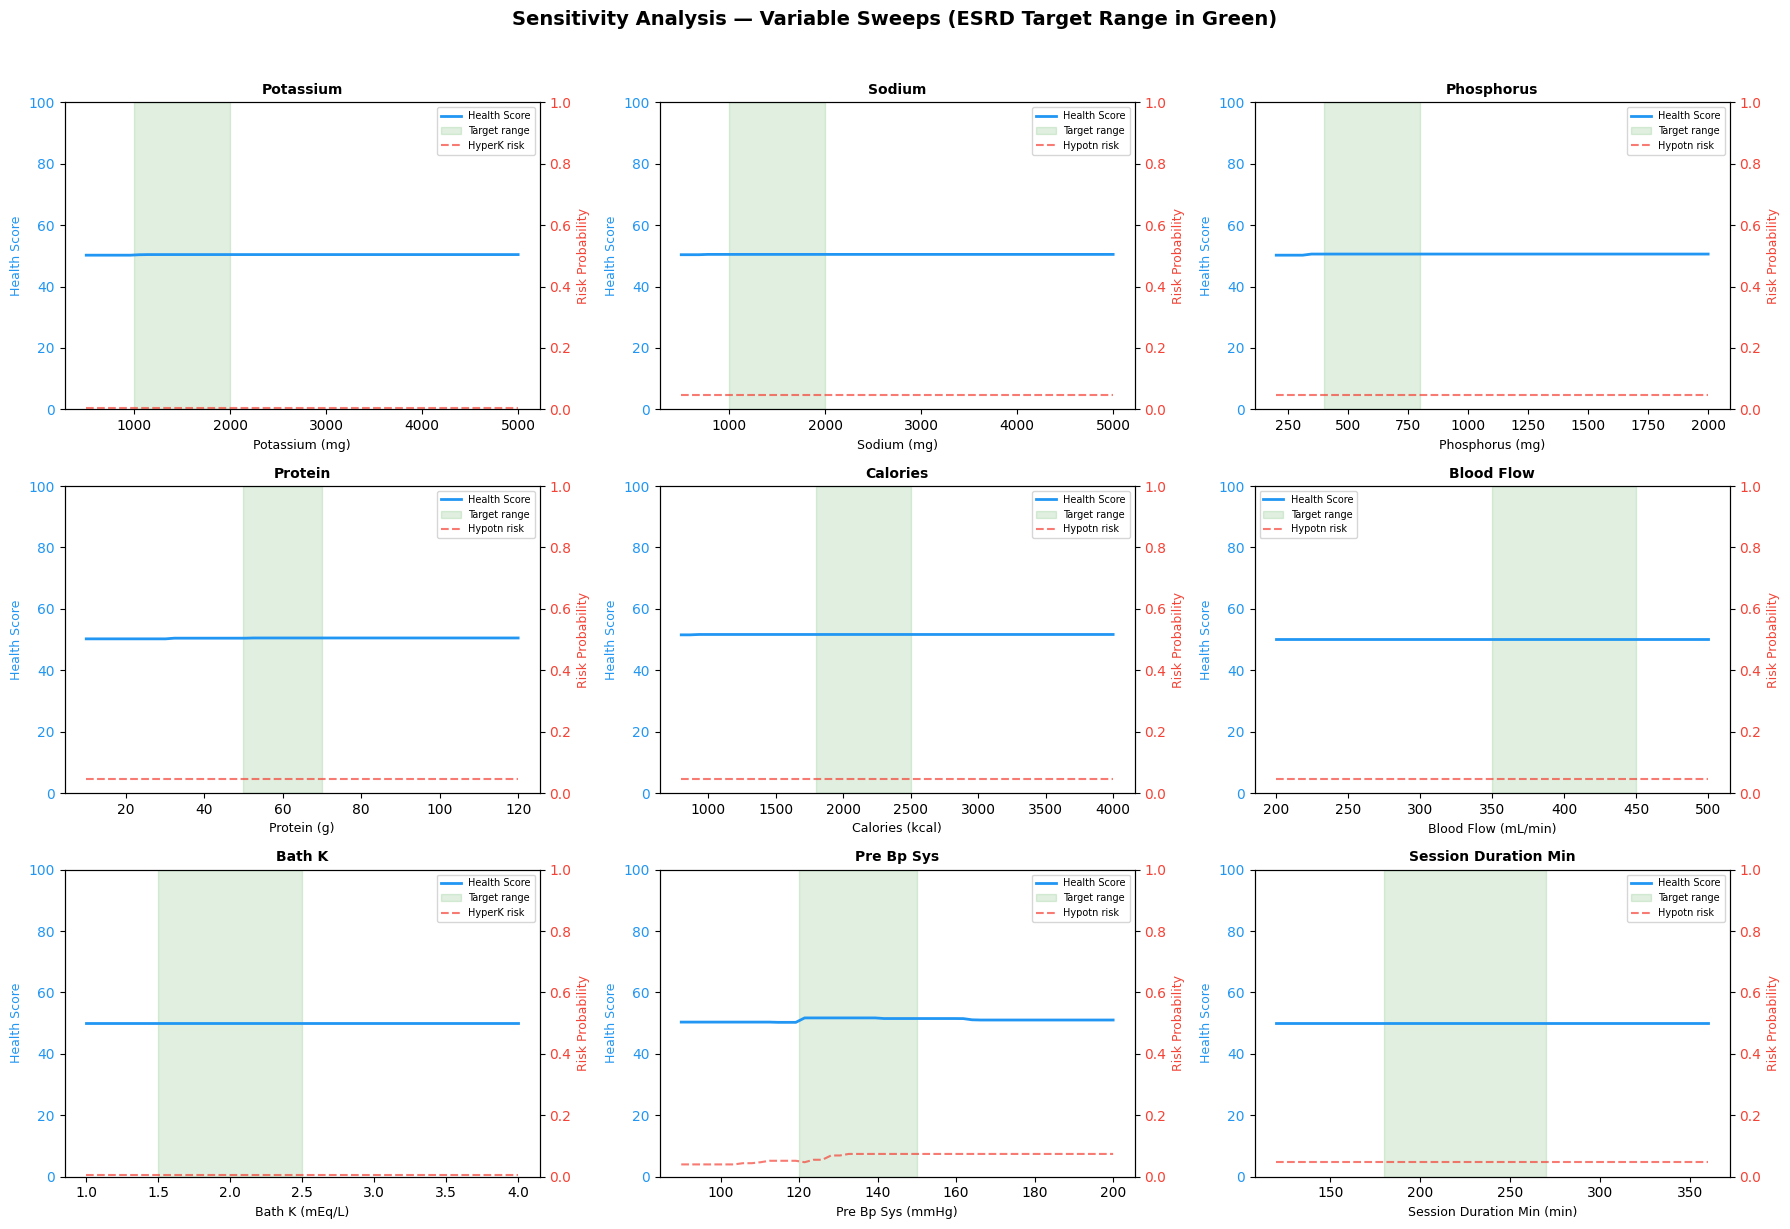

Saved: whatif_sensitivity_sweeps.png


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 7: Plot Sensitivity Curves
# ═══════════════════════════════════════════════════════════

n_vars = len(sweep_results)
ncols = 3
nrows = (n_vars + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for idx, (var_name, data) in enumerate(sweep_results.items()):
    ax = axes[idx]
    vals = data['values']
    rlo, rhi = data['range']
    
    # Health score (left y-axis)
    color1 = '#2196F3'
    ax.plot(vals, data['scores'], '-', color=color1, linewidth=2, label='Health Score')
    ax.set_ylabel('Health Score', color=color1, fontsize=9)
    ax.tick_params(axis='y', labelcolor=color1)
    ax.set_ylim(0, 100)
    
    # ESRD target range
    ax.axvspan(rlo, rhi, alpha=0.12, color='green', label='Target range')
    
    # Risk (right y-axis)
    ax2 = ax.twinx()
    color2 = '#F44336'
    if var_name in ('potassium', 'bath_k'):
        ax2.plot(vals, data['risk_hyperkalemia'], '--', color=color2, linewidth=1.5, alpha=0.7, label='HyperK risk')
    else:
        ax2.plot(vals, data['risk_hypotension'], '--', color=color2, linewidth=1.5, alpha=0.7, label='Hypotn risk')
    ax2.set_ylabel('Risk Probability', color=color2, fontsize=9)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(0, 1)
    
    ax.set_xlabel(f'{var_name.replace("_", " ").title()} ({data["unit"]})', fontsize=9)
    ax.set_title(f'{var_name.replace("_", " ").title()}', fontweight='bold', fontsize=10)
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=7)

# Hide unused axes
for idx in range(n_vars, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Sensitivity Analysis — Variable Sweeps (ESRD Target Range in Green)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'whatif_sensitivity_sweeps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: whatif_sensitivity_sweeps.png')

---
## Part 3b: Enhanced Visualizations — Log / %-Change / SymLog Scales

Linear axes can mask subtle but clinically meaningful variations. This section
re-renders the key plots with alternative bases:

| Plot | Standard issue | Enhanced scale |
|------|---------------|----------------|
| Sensitivity sweeps | 0–100 health, 0–1 risk | **% Δ from baseline** (centered at 0) + **symlog risk** |
| Scenario comparison | 0–1 bars | **log₁₀ risk** (reveals order-of-magnitude differences) |
| Dialysate heatmap | Linear colorbar | **LogNorm** risk colorbars (gradient appears at low-probability end) |
| Trajectory risks | 0–1 linear | **symlog** (expands the clinically important <0.1 zone) |

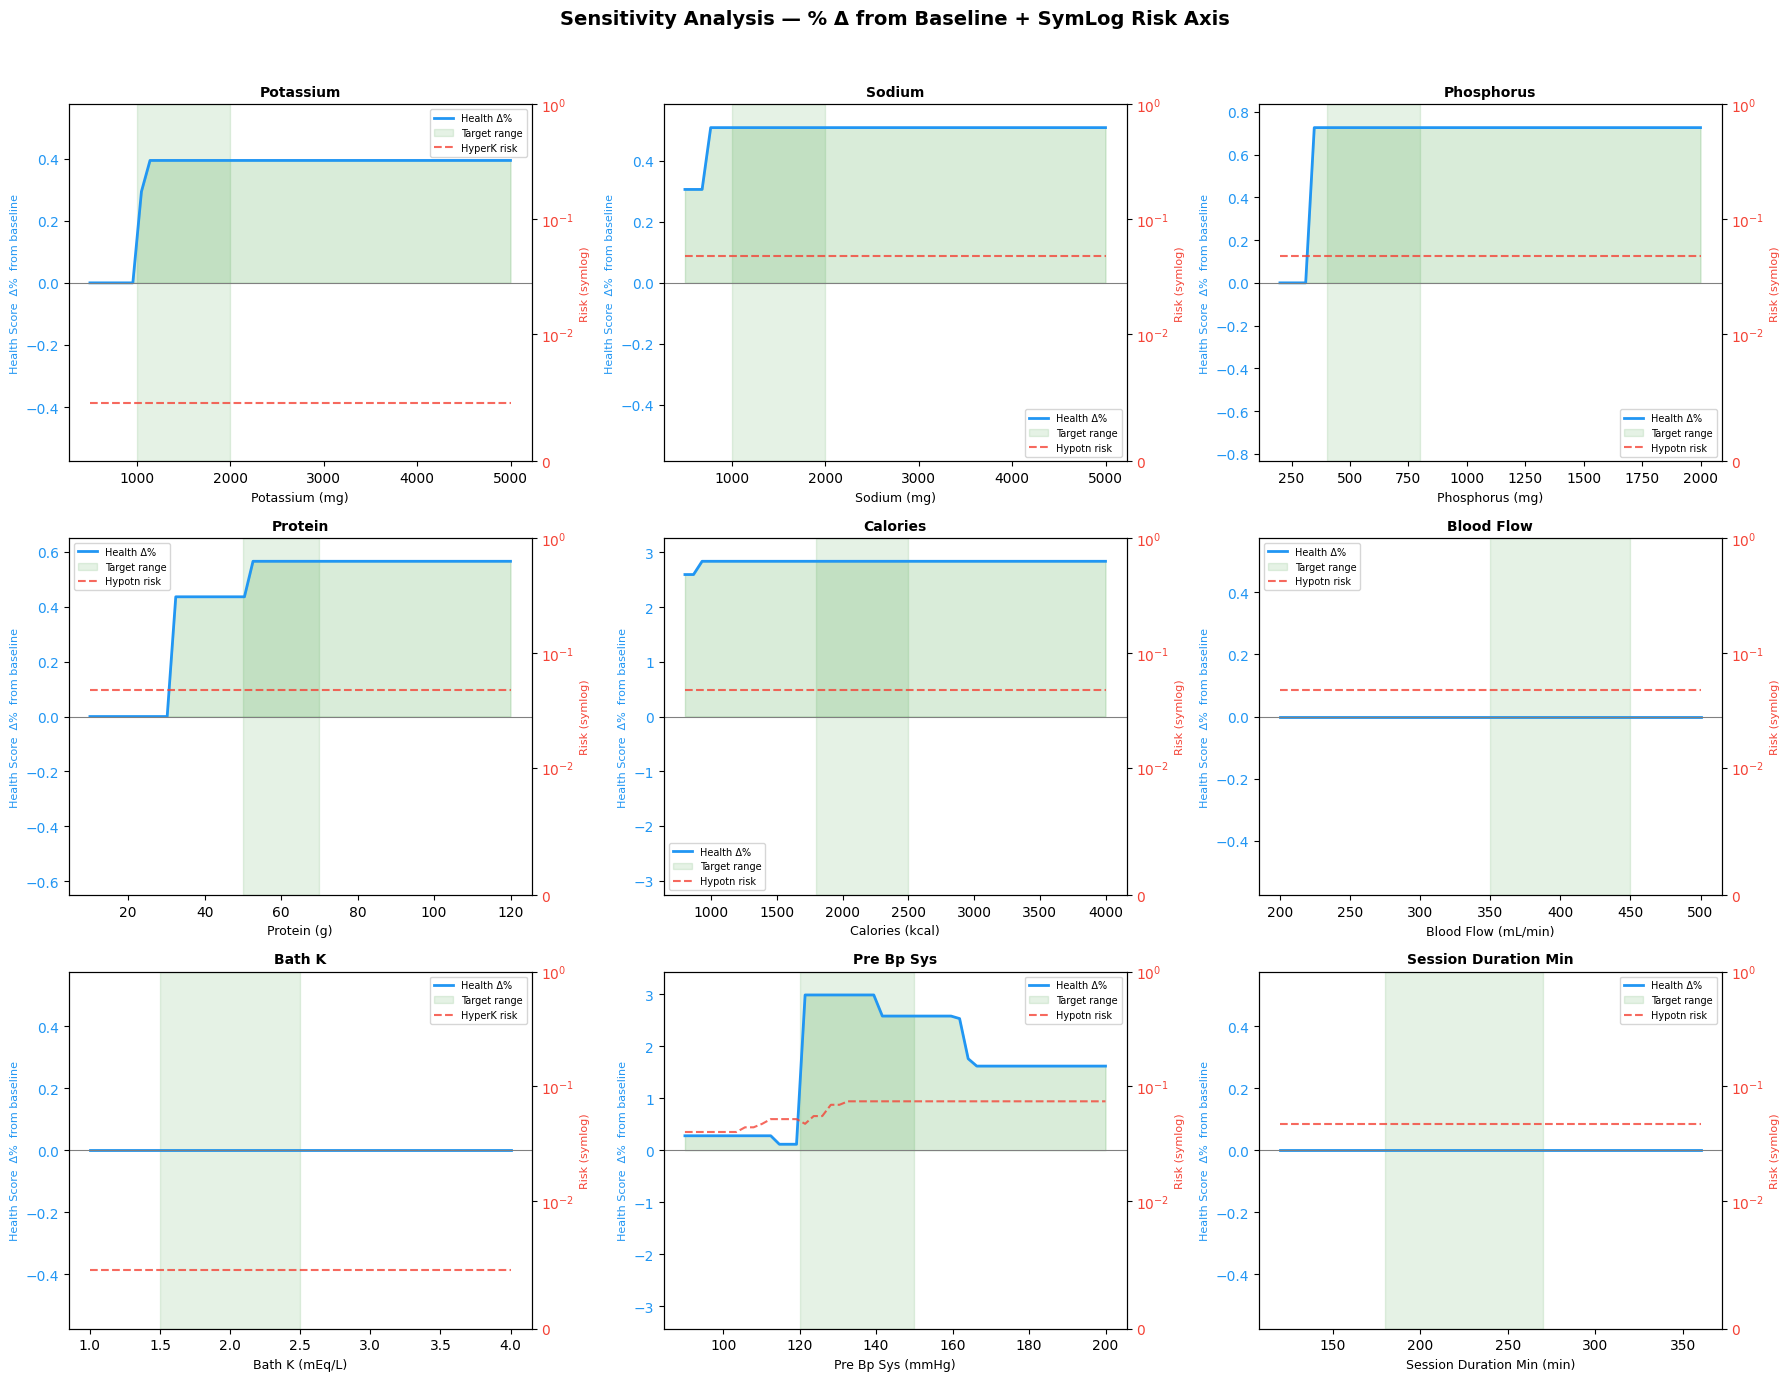

Saved: whatif_sensitivity_enhanced.png


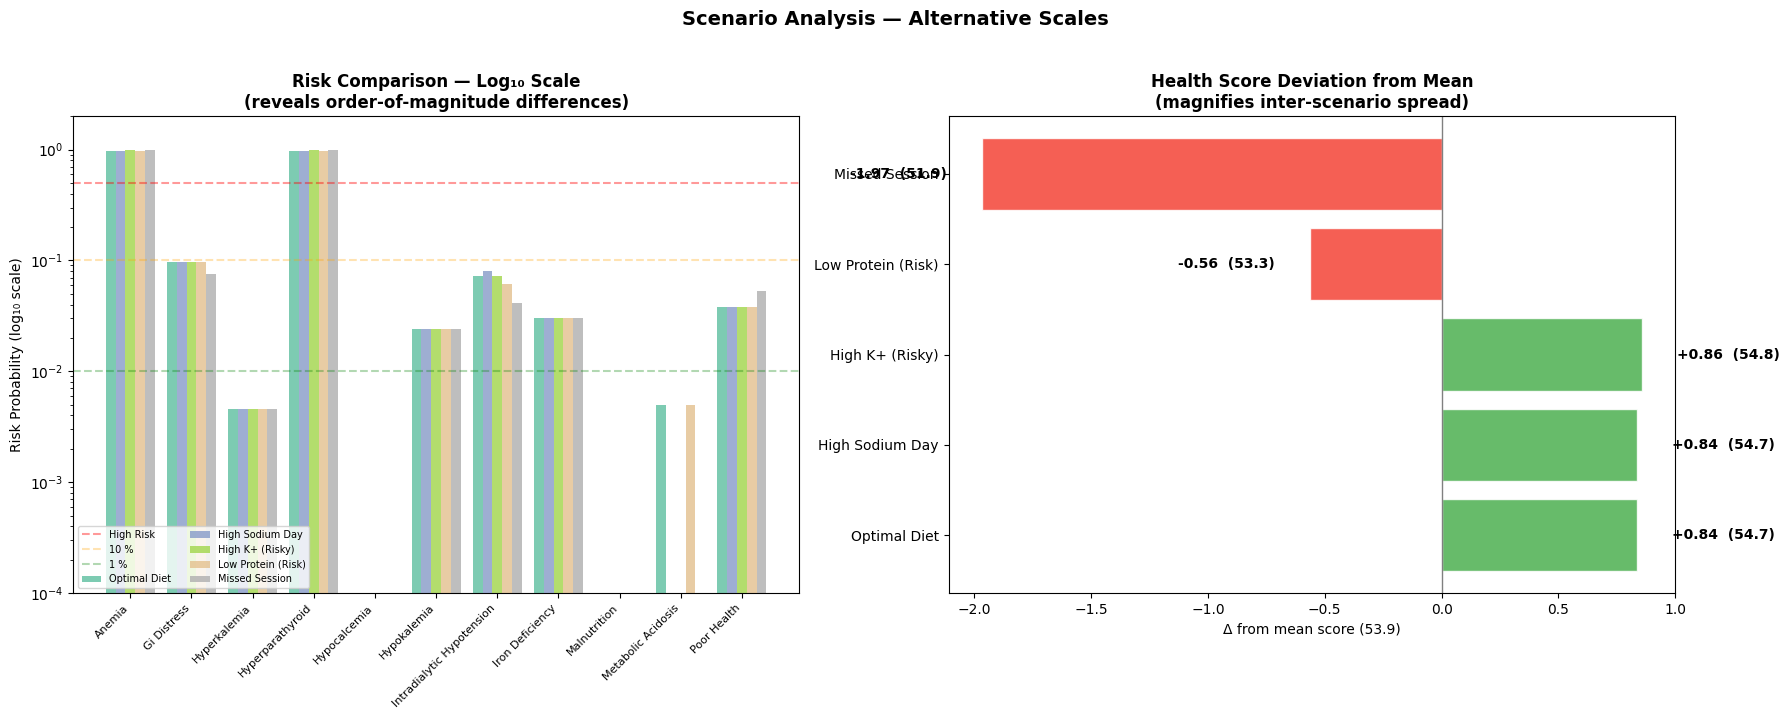

Saved: whatif_scenario_log.png


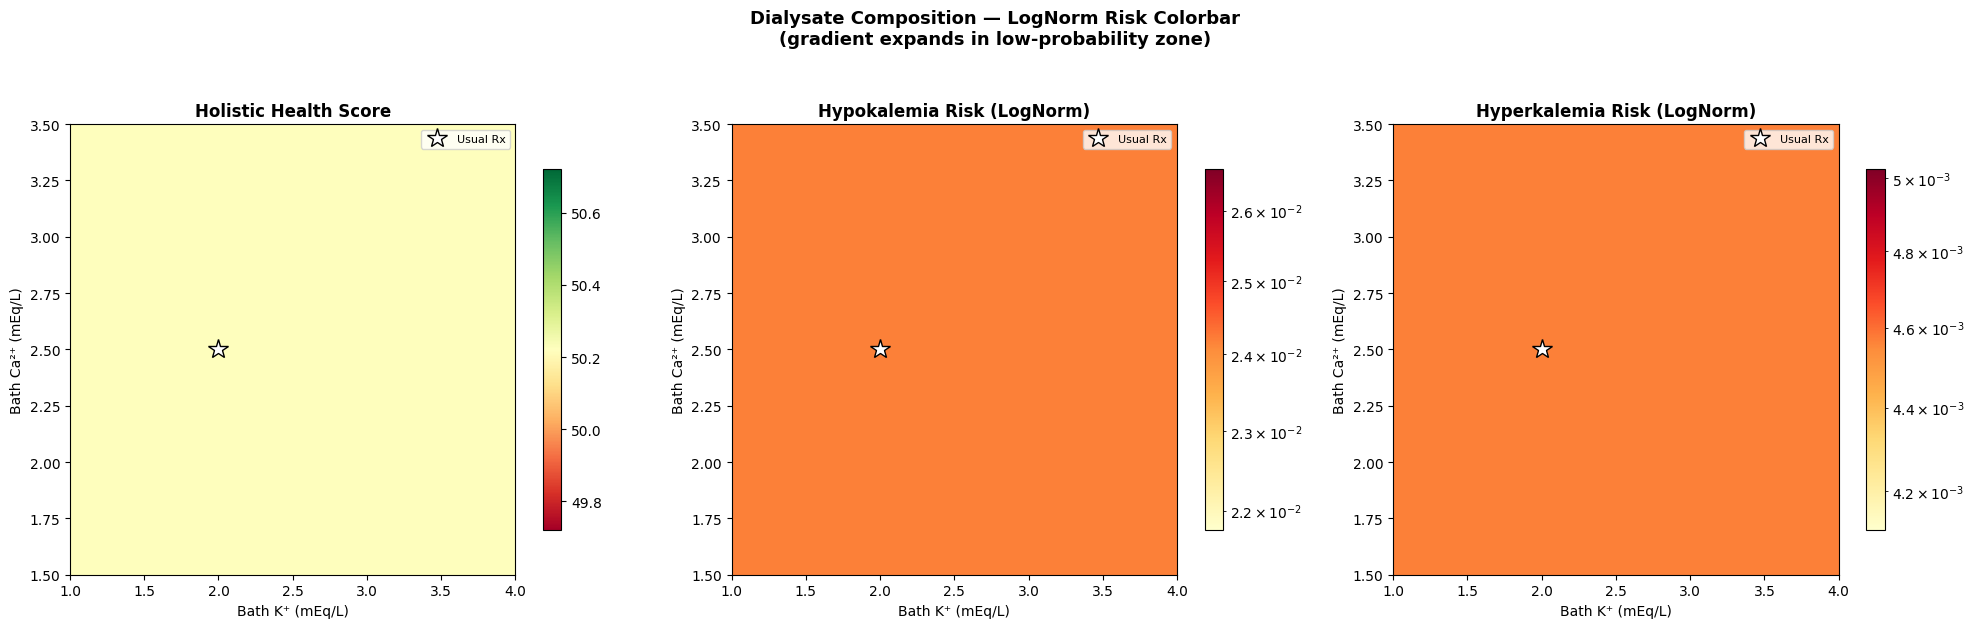

Saved: whatif_dialysate_lognorm.png


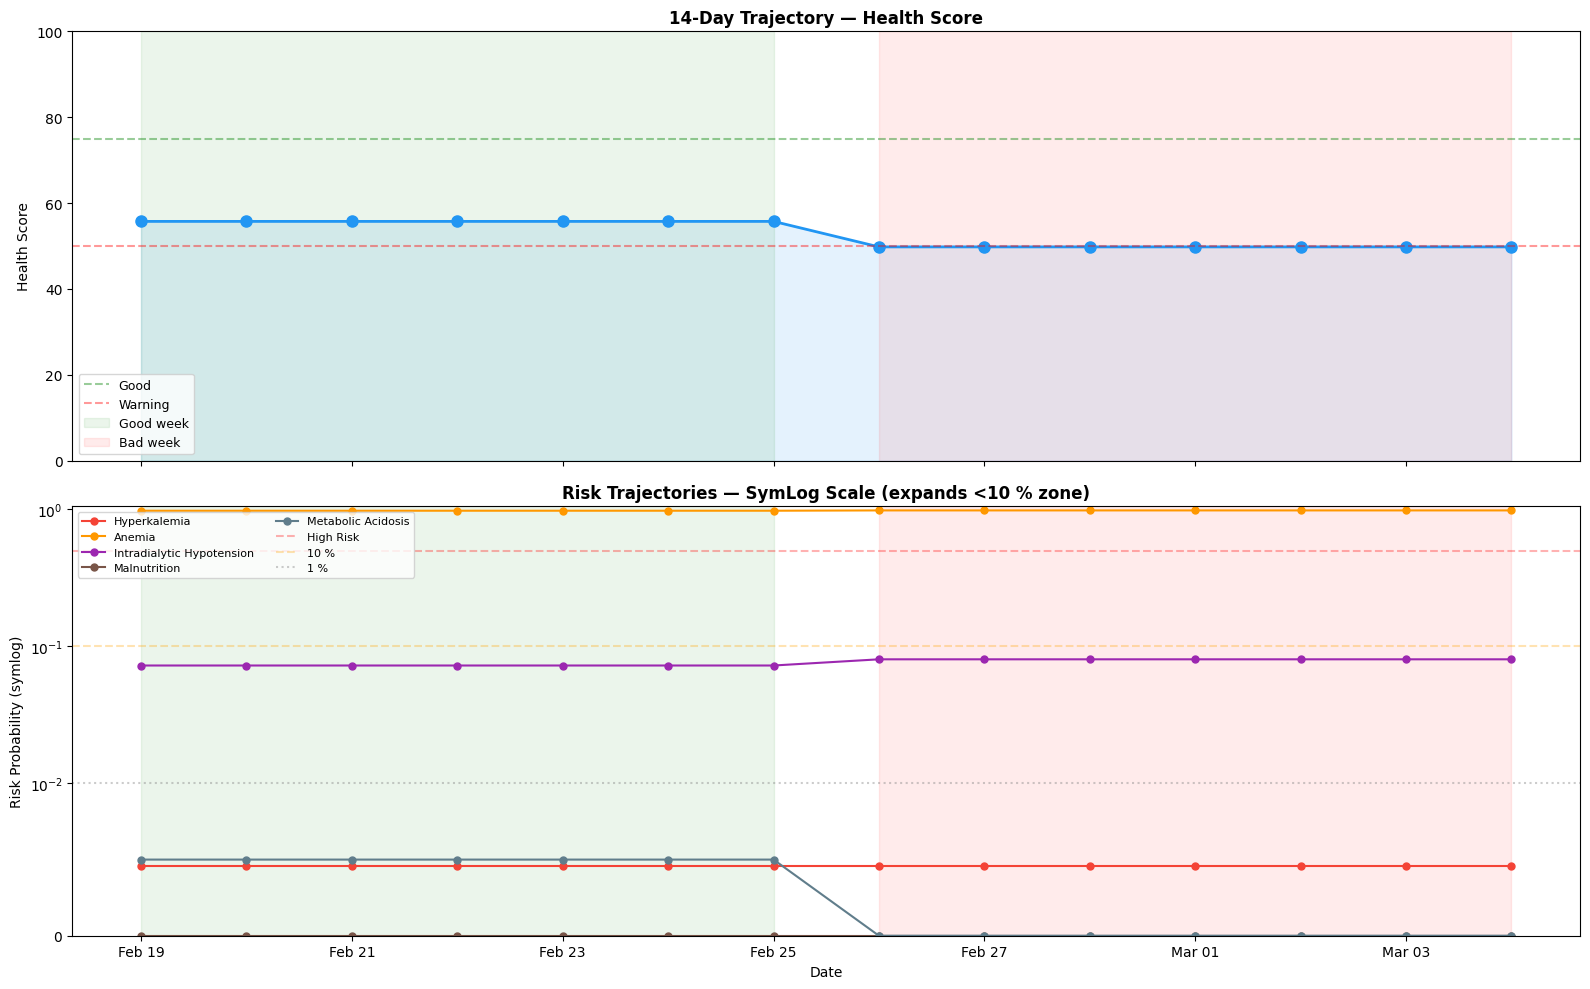

Saved: whatif_trajectory_symlog.png

✓ All 4 enhanced-scale visualizations saved.


In [12]:
# ═══════════════════════════════════════════════════════════
# CELL 7b: Enhanced-Scale Visualizations
#   1. Sensitivity: % Δ from baseline + symlog risk
#   2. Scenario comparison: log₁₀ risk bars
#   3. Dialysate heatmap: LogNorm risk
#   4. Trajectory: symlog risk axis
# ═══════════════════════════════════════════════════════════

from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.ticker import SymmetricalLogLocator, LogLocator, FuncFormatter

# ────────────────────────────────────────────────────────────
# 1. SENSITIVITY SWEEPS — % change from baseline + symlog risk
# ────────────────────────────────────────────────────────────
baseline_score = predict_whatif({}, verbose=False)['holistic_score']

n_vars = len(sweep_results)
ncols = 3
nrows = (n_vars + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows))
axes = axes.flatten()

for idx, (var_name, data) in enumerate(sweep_results.items()):
    ax = axes[idx]
    vals = data['values']
    rlo, rhi = data['range']
    s = np.array(data['scores'])

    # --- Left axis: % Δ from baseline (centered at 0 = baseline) ---
    pct_delta = 100.0 * (s - baseline_score) / baseline_score
    color1 = '#2196F3'
    ax.plot(vals, pct_delta, '-', color=color1, linewidth=2, label='Health Δ%')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='-')
    ax.set_ylabel('Health Score  Δ%  from baseline', color=color1, fontsize=8)
    ax.tick_params(axis='y', labelcolor=color1)

    # Auto-range: at least ±0.5 % to avoid a flat line illusion
    yabs = max(np.abs(pct_delta).max(), 0.5) * 1.15
    ax.set_ylim(-yabs, yabs)

    # Fill positive green / negative red
    ax.fill_between(vals, 0, pct_delta, where=(pct_delta >= 0),
                     interpolate=True, alpha=0.15, color='green')
    ax.fill_between(vals, 0, pct_delta, where=(pct_delta < 0),
                     interpolate=True, alpha=0.15, color='red')

    # ESRD target shading
    ax.axvspan(rlo, rhi, alpha=0.10, color='green', label='Target range')

    # --- Right axis: risk on symlog scale ---
    ax2 = ax.twinx()
    color2 = '#F44336'
    if var_name in ('potassium', 'bath_k'):
        risk_data = np.array(data['risk_hyperkalemia'])
        rlabel = 'HyperK risk'
    else:
        risk_data = np.array(data['risk_hypotension'])
        rlabel = 'Hypotn risk'

    ax2.plot(vals, risk_data, '--', color=color2, linewidth=1.5, alpha=0.8, label=rlabel)
    ax2.set_yscale('symlog', linthresh=0.01)          # expands the 0–0.01 band
    ax2.set_ylabel(f'Risk (symlog)', color=color2, fontsize=8)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(0, 1)

    ax.set_xlabel(f'{var_name.replace("_"," ").title()} ({data["unit"]})', fontsize=9)
    ax.set_title(f'{var_name.replace("_"," ").title()}', fontweight='bold', fontsize=10)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=7)

for idx in range(n_vars, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Sensitivity Analysis — % Δ from Baseline + SymLog Risk Axis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'whatif_sensitivity_enhanced.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: whatif_sensitivity_enhanced.png')

# ────────────────────────────────────────────────────────────
# 2. SCENARIO COMPARISON — log₁₀ risk bars
# ────────────────────────────────────────────────────────────
risk_cols = [c for c in comp_df.columns if c.startswith('risk_')]
risk_labels = [c.replace('risk_', '').replace('_', ' ').title() for c in risk_cols]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: log₁₀ risk probabilities
ax = axes[0]
n_scenarios = len(comp_df)
n_risks = len(risk_cols)
x = np.arange(n_risks)
width = 0.8 / n_scenarios
colors = plt.cm.Set2(np.linspace(0, 1, n_scenarios))

for i, (sc_name, row) in enumerate(comp_df.iterrows()):
    vals = np.array([row[c] for c in risk_cols])
    # Clamp zeros for log: replace 0 with a small floor
    vals_log = np.where(vals > 0, vals, 1e-6)
    ax.bar(x + i * width, vals_log, width, label=sc_name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * (n_scenarios - 1) / 2)
ax.set_xticklabels(risk_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Risk Probability (log₁₀ scale)')
ax.set_yscale('log')
ax.set_ylim(1e-4, 2)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='High Risk')
ax.axhline(y=0.1, color='orange', linestyle='--', alpha=0.3, label='10 %')
ax.axhline(y=0.01, color='green', linestyle='--', alpha=0.3, label='1 %')
ax.set_title('Risk Comparison — Log₁₀ Scale\n(reveals order-of-magnitude differences)',
             fontweight='bold')
ax.legend(loc='lower left', fontsize=7, ncol=2)

# Right: score deviation from mean scenario
ax = axes[1]
sc_names = list(comp_df.index)
scores = comp_df['holistic_score'].values
mean_sc = scores.mean()
deltas = scores - mean_sc
bar_colors = ['#4CAF50' if d >= 0 else '#F44336' for d in deltas]
bars = ax.barh(sc_names, deltas, color=bar_colors, alpha=0.85, edgecolor='white')

for bar, d, s in zip(bars, deltas, scores):
    x_pos = bar.get_width() + (0.15 if d >= 0 else -0.15)
    ha = 'left' if d >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{d:+.2f}  ({s:.1f})', va='center', ha=ha, fontweight='bold', fontsize=10)

ax.axvline(0, color='gray', linewidth=1)
ax.set_xlabel(f'Δ from mean score ({mean_sc:.1f})')
ax.set_title('Health Score Deviation from Mean\n(magnifies inter-scenario spread)',
             fontweight='bold')

plt.suptitle('Scenario Analysis — Alternative Scales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'whatif_scenario_log.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: whatif_scenario_log.png')

# ────────────────────────────────────────────────────────────
# 3. DIALYSATE HEATMAP — LogNorm risk color scale
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, data_mat, title, cmap in [
    (axes[0], heatmap_health, 'Holistic Health Score', 'RdYlGn'),
    (axes[1], heatmap_hypoK,  'Hypokalemia Risk (LogNorm)', 'YlOrRd'),
    (axes[2], heatmap_hyperK, 'Hyperkalemia Risk (LogNorm)', 'YlOrRd'),
]:
    ext = [bath_k_range[0], bath_k_range[-1], bath_ca_range[0], bath_ca_range[-1]]
    if 'Risk' in title:
        # LogNorm: highlight low-end gradient
        vmin_r = max(data_mat[data_mat > 0].min(), 1e-5) if (data_mat > 0).any() else 1e-5
        vmax_r = data_mat.max()
        norm = LogNorm(vmin=vmin_r, vmax=vmax_r)
        im = ax.imshow(data_mat, origin='lower', aspect='auto',
                       cmap=cmap, norm=norm, extent=ext)
    else:
        # Health score: use centered diverging norm around median
        med_h = np.median(data_mat)
        halfspan = max(data_mat.max() - med_h, med_h - data_mat.min(), 0.5)
        im = ax.imshow(data_mat, origin='lower', aspect='auto',
                       cmap=cmap, vmin=med_h - halfspan, vmax=med_h + halfspan,
                       extent=ext)
    ax.set_xlabel('Bath K⁺ (mEq/L)')
    ax.set_ylabel('Bath Ca²⁺ (mEq/L)')
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.plot(2.0, 2.5, 'w*', markersize=15, markeredgecolor='black', label='Usual Rx')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Dialysate Composition — LogNorm Risk Colorbar\n(gradient expands in low-probability zone)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'whatif_dialysate_lognorm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: whatif_dialysate_lognorm.png')

# ────────────────────────────────────────────────────────────
# 4. TRAJECTORY — symlog risk axis
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Top: health score — log-delta from 50 (neutral)
ax = axes[0]
hs = traj['holistic_score'].values
ax.plot(traj.index, hs, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax.fill_between(traj.index, 0, hs, alpha=0.12, color='#2196F3')
ax.axhline(75, color='green', ls='--', alpha=0.4, label='Good')
ax.axhline(50, color='red', ls='--', alpha=0.4, label='Warning')
ax.axvspan(traj.index[0], traj.index[6], alpha=0.08, color='green', label='Good week')
ax.axvspan(traj.index[7], traj.index[13], alpha=0.08, color='red', label='Bad week')
ax.set_ylabel('Health Score')
ax.set_title('14-Day Trajectory — Health Score', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.set_ylim(0, 100)

# Bottom: risks on symlog
ax = axes[1]
risk_keys_traj = ['risk_hyperkalemia', 'risk_anemia', 'risk_intradialytic_hypotension',
                  'risk_malnutrition', 'risk_metabolic_acidosis']
colors_risk = ['#F44336', '#FF9800', '#9C27B0', '#795548', '#607D8B']

for rk, clr in zip(risk_keys_traj, colors_risk):
    if rk in traj.columns:
        label = rk.replace('risk_', '').replace('_', ' ').title()
        ax.plot(traj.index, traj[rk], 'o-', color=clr, linewidth=1.5,
                markersize=5, label=label)

ax.set_yscale('symlog', linthresh=0.01)
ax.set_ylabel('Risk Probability (symlog)')
ax.set_xlabel('Date')
ax.axhline(0.5, color='red', ls='--', alpha=0.3, label='High Risk')
ax.axhline(0.1, color='orange', ls='--', alpha=0.3, label='10 %')
ax.axhline(0.01, color='gray', ls=':', alpha=0.4, label='1 %')
ax.axvspan(traj.index[0], traj.index[6], alpha=0.08, color='green')
ax.axvspan(traj.index[7], traj.index[13], alpha=0.08, color='red')
ax.set_title('Risk Trajectories — SymLog Scale (expands <10 % zone)', fontweight='bold')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.savefig(FEATURES_DIR / 'whatif_trajectory_symlog.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: whatif_trajectory_symlog.png')

print('\n✓ All 4 enhanced-scale visualizations saved.')

---
## Part 4: Temporal What-If — Multi-Day Trajectory Simulation

Simulate N days of a repeated scenario and project wellness trajectory.

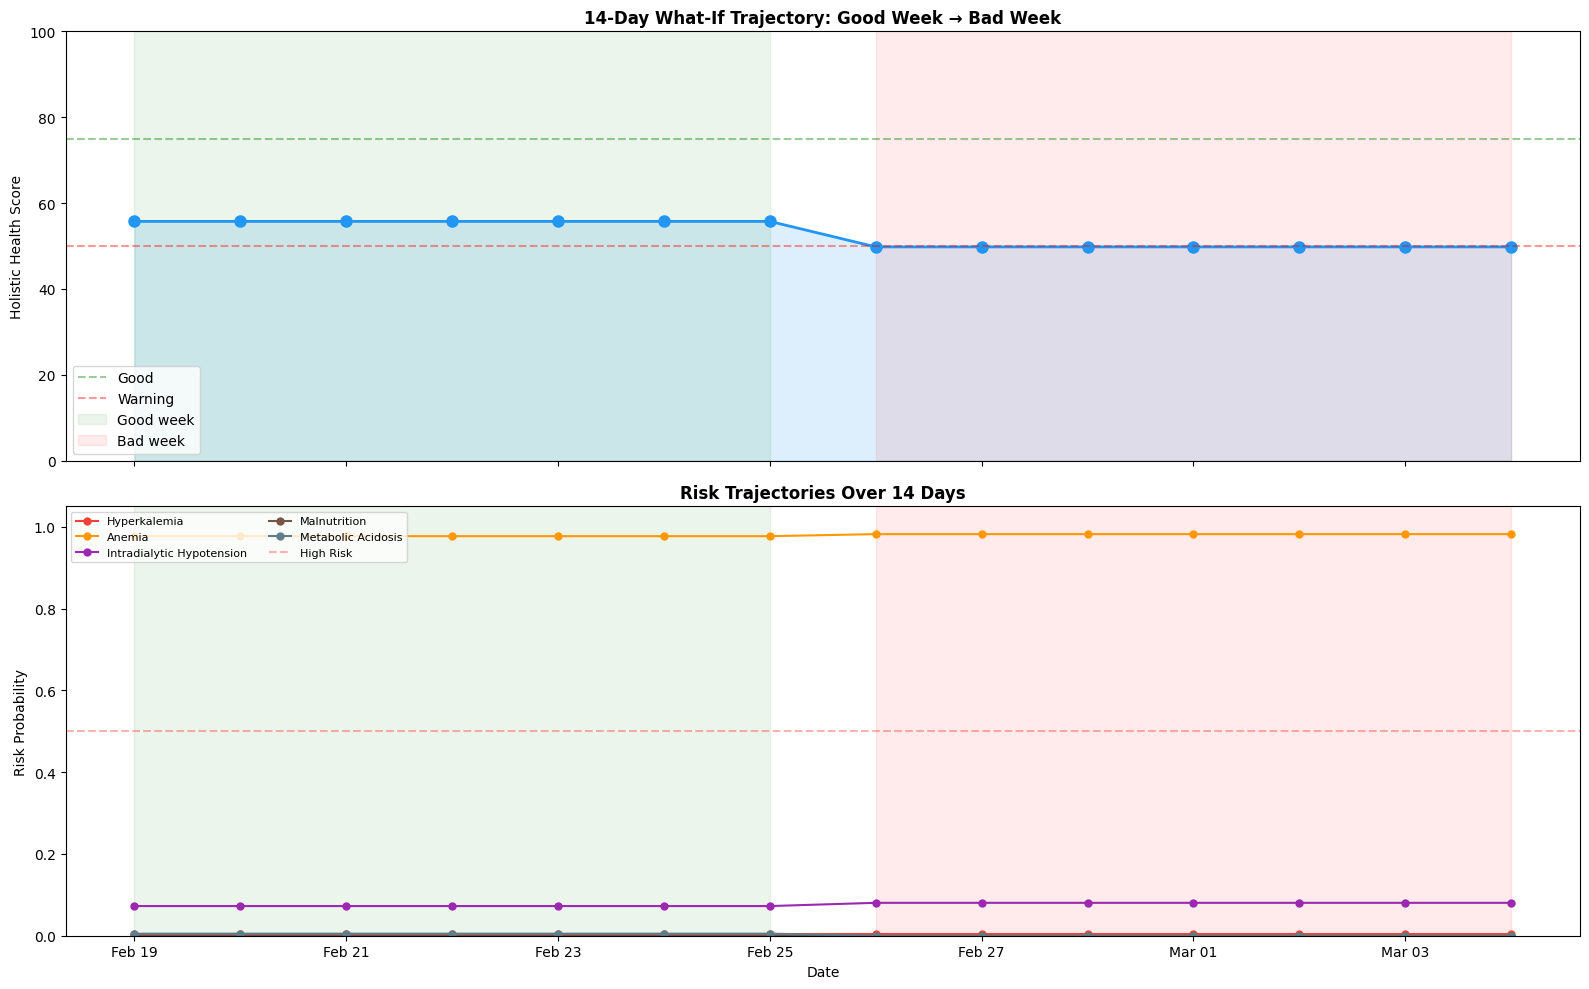

Saved: whatif_trajectory_14d.png


In [9]:
# ═══════════════════════════════════════════════════════════
# CELL 8: Multi-Day Trajectory Simulation
# ═══════════════════════════════════════════════════════════

def simulate_trajectory(daily_scenarios: list, start_date: str = '2026-02-19',
                        carry_forward: bool = True) -> pd.DataFrame:
    """
    Simulate N days. Each entry in daily_scenarios is a scenario dict.
    If carry_forward=True, lab-based features accumulate (e.g., 7d rolling).
    """
    start = pd.Timestamp(start_date)
    trajectory = []
    
    for i, scenario in enumerate(daily_scenarios):
        date = start + timedelta(days=i)
        results = predict_whatif(scenario, verbose=False)
        results['date'] = date
        results['day'] = i + 1
        trajectory.append(results)
    
    df_traj = pd.DataFrame(trajectory)
    df_traj.set_index('date', inplace=True)
    return df_traj


# ── Simulate 14-day trajectory: Good week then bad week ──
good_day = {
    'calories': 2100, 'protein': 60, 'sodium': 1500, 'potassium': 1200,
    'phosphorus': 600, 'calcium': 800, 'iron': 10, 'fiber': 25, 'sugar': 30,
    'pre_weight': 54.5, 'post_weight': 53.0, 'blood_flow': 400,
    'bath_k': 2.0, 'bath_ca': 2.5, 'session_duration_min': 240,
    'calcium_carbonate_doses': 3, 'calcitriol_doses': 1,
    'sessions_7d': 4, 'active_days_7d': 5,
}

bad_day = {
    'calories': 3200, 'protein': 30, 'sodium': 3500, 'potassium': 3000,
    'phosphorus': 1200, 'calcium': 300, 'iron': 3, 'fiber': 8, 'sugar': 100,
    'pre_weight': 57.0, 'post_weight': 53.0, 'blood_flow': 300,
    'bath_k': 3.0, 'bath_ca': 2.0, 'session_duration_min': 180,
    'calcium_carbonate_doses': 0, 'calcitriol_doses': 0,
    'sessions_7d': 2, 'active_days_7d': 2,
}

# 7 good days + 7 bad days
daily_plans = [good_day] * 7 + [bad_day] * 7
traj = simulate_trajectory(daily_plans)

# ── Plot trajectory ──
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Health score
ax = axes[0]
ax.plot(traj.index, traj['holistic_score'], 'o-', color='#2196F3', linewidth=2, markersize=8)
ax.fill_between(traj.index, 0, traj['holistic_score'], alpha=0.15, color='#2196F3')
ax.axhline(75, color='green', linestyle='--', alpha=0.4, label='Good')
ax.axhline(50, color='red', linestyle='--', alpha=0.4, label='Warning')
ax.axvspan(traj.index[0], traj.index[6], alpha=0.08, color='green', label='Good week')
ax.axvspan(traj.index[7], traj.index[13], alpha=0.08, color='red', label='Bad week')
ax.set_ylabel('Holistic Health Score')
ax.set_title('14-Day What-If Trajectory: Good Week → Bad Week', fontweight='bold')
ax.legend(loc='lower left')
ax.set_ylim(0, 100)

# Key risks
ax = axes[1]
risk_keys = ['risk_hyperkalemia', 'risk_anemia', 'risk_intradialytic_hypotension',
             'risk_malnutrition', 'risk_metabolic_acidosis']
colors_risk = ['#F44336', '#FF9800', '#9C27B0', '#795548', '#607D8B']
for rk, clr in zip(risk_keys, colors_risk):
    if rk in traj.columns:
        label = rk.replace('risk_', '').replace('_', ' ').title()
        ax.plot(traj.index, traj[rk], 'o-', color=clr, linewidth=1.5, markersize=5, label=label)

ax.axhline(0.5, color='red', linestyle='--', alpha=0.3, label='High Risk')
ax.axvspan(traj.index[0], traj.index[6], alpha=0.08, color='green')
ax.axvspan(traj.index[7], traj.index[13], alpha=0.08, color='red')
ax.set_ylabel('Risk Probability')
ax.set_xlabel('Date')
ax.set_title('Risk Trajectories Over 14 Days', fontweight='bold')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.savefig(FEATURES_DIR / 'whatif_trajectory_14d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: whatif_trajectory_14d.png')

---
## Part 5: Dialysate Composition What-If

Explore the interaction between bath K⁺, bath Ca²⁺, blood flow, and session time.

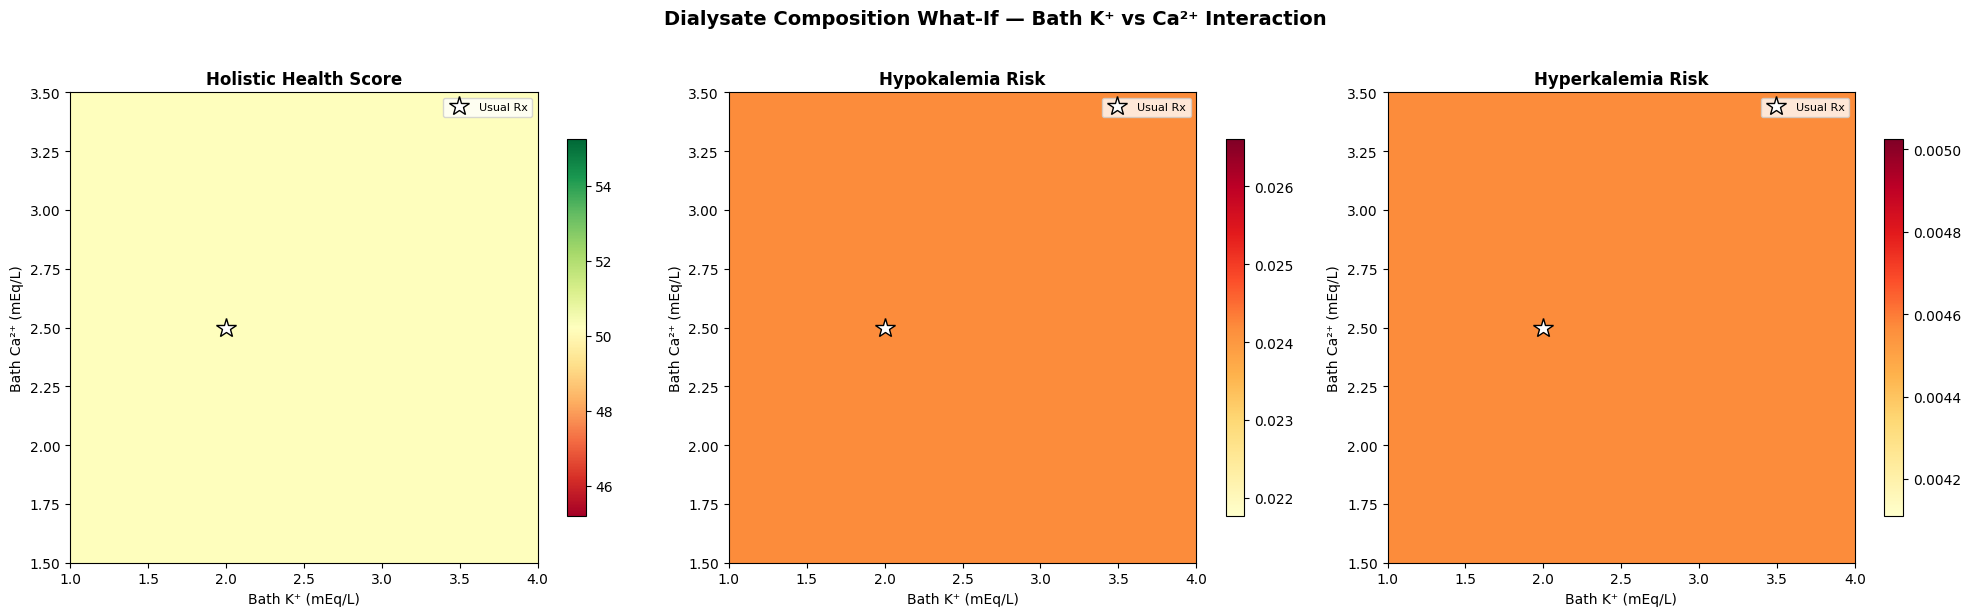

Saved: whatif_dialysate_heatmap.png


In [10]:
# ═══════════════════════════════════════════════════════════
# CELL 9: Dialysate Composition 2D Heatmap
# ═══════════════════════════════════════════════════════════

# Sweep bath_k vs bath_ca → health score heatmap
bath_k_range = np.linspace(1.0, 4.0, 25)
bath_ca_range = np.linspace(1.5, 3.5, 25)

heatmap_health = np.zeros((len(bath_ca_range), len(bath_k_range)))
heatmap_hypoK = np.zeros_like(heatmap_health)
heatmap_hyperK = np.zeros_like(heatmap_health)

for i, ca in enumerate(bath_ca_range):
    for j, k in enumerate(bath_k_range):
        sc = {'bath_ca': ca, 'bath_k': k, 'blood_flow': 400, 'session_duration_min': 240}
        r = predict_whatif(sc, verbose=False)
        heatmap_health[i, j] = r['holistic_score']
        heatmap_hypoK[i, j] = r.get('risk_hypokalemia', 0)
        heatmap_hyperK[i, j] = r.get('risk_hyperkalemia', 0)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, data, title, cmap in [
    (axes[0], heatmap_health, 'Holistic Health Score', 'RdYlGn'),
    (axes[1], heatmap_hypoK, 'Hypokalemia Risk', 'YlOrRd'),
    (axes[2], heatmap_hyperK, 'Hyperkalemia Risk', 'YlOrRd'),
]:
    im = ax.imshow(data, origin='lower', aspect='auto', cmap=cmap,
                   extent=[bath_k_range[0], bath_k_range[-1],
                           bath_ca_range[0], bath_ca_range[-1]])
    ax.set_xlabel('Bath K⁺ (mEq/L)')
    ax.set_ylabel('Bath Ca²⁺ (mEq/L)')
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8)
    # Mark typical prescription
    ax.plot(2.0, 2.5, 'w*', markersize=15, markeredgecolor='black', label='Usual Rx')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Dialysate Composition What-If — Bath K⁺ vs Ca²⁺ Interaction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'whatif_dialysate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: whatif_dialysate_heatmap.png')

---
## Part 6: Food-Specific What-If

Enter specific food items and get predicted health impact using backfill nutrient estimates.

In [11]:
# ═══════════════════════════════════════════════════════════
# CELL 10: Food Item Database & Lookup
# ═══════════════════════════════════════════════════════════

# Build a food nutrient database from backfill items_json
print('Building food nutrient database from backfill data...')
df_backfill = pd.read_csv(DATA_DIR / 'nutrition_backfill' / 'nutrition_backfilled.csv')

food_db = []
for _, row in df_backfill.iterrows():
    try:
        items = json.loads(row['items_json'])
        for item in items:
            food_db.append(item)
    except:
        pass

df_foods = pd.DataFrame(food_db)
# Deduplicate by name — take median nutrient values
nutrient_keys = ['calories', 'protein', 'carbs', 'fat', 'fiber', 'sugar',
                 'sodium', 'potassium', 'calcium', 'iron', 'phosphorus',
                 'cholesterol', 'vitamin_d', 'vitamin_b12', 'folic_acid']

for nk in nutrient_keys:
    if nk in df_foods.columns:
        df_foods[nk] = pd.to_numeric(df_foods[nk], errors='coerce')

food_median = df_foods.groupby('name')[nutrient_keys].median().reset_index()
food_median = food_median.dropna(subset=['calories'])
food_median = food_median.sort_values('name')

print(f'  Total food item records: {len(df_foods)}')
print(f'  Unique foods: {len(food_median)}')
print(f'\n  Sample foods:')
print(food_median[['name', 'calories', 'protein', 'sodium', 'potassium', 'phosphorus']].head(20).to_string(index=False))

Building food nutrient database from backfill data...
  Total food item records: 108218
  Unique foods: 1458

  Sample foods:
                 name  calories  protein  sodium  potassium  phosphorus
              0valtin     110.0      4.0   200.0      100.0       100.0
              1% milk     102.0      8.1   107.0      349.0       222.0
            365 Kefir     160.0     11.0   160.0      350.0       221.0
365 Kefir (Raspberry)     190.0     11.0   125.0      350.0       250.0
        365 Kefir Mix     160.0     10.0   160.0      350.0       220.0
    365 Kefir Yoghurt     145.0     11.0   145.0      350.0       220.0
365 Kefir yoghurt mix     160.0     10.0   150.0      350.0       220.0
 365 Strawberry Kefir     145.0      8.0   115.0      350.0       200.0
      365 Wheat Bread     160.0      8.0   320.0      120.0       160.0
      365 Wheat bread     130.0      6.0   230.0      100.0       120.0
          365 Yoghurt     220.0     12.0   160.0      350.0       300.0
          

In [13]:
# ═══════════════════════════════════════════════════════════
# CELL 11: Food-Based What-If — "What if I eat X today?"
# ═══════════════════════════════════════════════════════════

def food_whatif(food_list: list, food_db: pd.DataFrame = food_median) -> dict:
    """
    Given a list of food names, look up nutrients and predict outcomes.
    food_list: list of food name strings (fuzzy matched)
    Returns: (total_nutrients_dict, prediction_results, matched_foods_df)
    """
    matched = []
    for food_name in food_list:
        # Fuzzy match: find closest food in database
        mask = food_db['name'].str.contains(food_name.lower(), case=False, na=False)
        hits = food_db[mask]
        if len(hits) > 0:
            matched.append(hits.iloc[0])
        else:
            print(f"  ⚠️ '{food_name}' not found in database")
    
    if not matched:
        print('No foods matched!')
        return None, None, None
    
    df_matched = pd.DataFrame(matched)
    
    # Sum nutrients
    totals = df_matched[nutrient_keys].sum()
    
    # Build scenario
    scenario = {k: totals[k] for k in nutrient_keys if pd.notna(totals.get(k, np.nan))}
    
    print(f"\n{'═'*60}")
    print(f"  FOOD WHAT-IF: {len(matched)} items")
    print(f"{'═'*60}")
    print(f"\n  Foods matched:")
    for _, row in df_matched.iterrows():
        print(f"    • {row['name']}: {row['calories']:.0f} cal, {row['protein']:.1f}g protein")
    
    print(f"\n  Daily Totals:")
    print(f"    Calories:    {totals['calories']:.0f} kcal")
    print(f"    Protein:     {totals['protein']:.1f} g")
    print(f"    Sodium:      {totals['sodium']:.0f} mg")
    print(f"    Potassium:   {totals['potassium']:.0f} mg")
    print(f"    Phosphorus:  {totals['phosphorus']:.0f} mg")
    
    # ESRD limit checks
    limits = {'sodium': 2000, 'potassium': 2000, 'phosphorus': 800}
    for nutrient, limit in limits.items():
        val = totals.get(nutrient, 0)
        if val > limit:
            print(f"    ⚠️  {nutrient.title()} ({val:.0f}) EXCEEDS limit ({limit} mg)!")
    
    results = predict_whatif(scenario)
    return totals.to_dict(), results, df_matched


# ── Example: What if I eat these foods today? ──
my_foods = [
    'white rice',
    'grilled chicken',
    'banana',
    'white bread',
    'egg',
]

totals, results, matched = food_whatif(my_foods)


════════════════════════════════════════════════════════════
  FOOD WHAT-IF: 5 items
════════════════════════════════════════════════════════════

  Foods matched:
    • Basmati White Rice: 206 cal, 4.3g protein
    • Grilled chicken liver: 165 cal, 24.0g protein
    • Banana: 105 cal, 1.1g protein
    • Lancaster White Bread: 130 cal, 4.0g protein
    • Boiled Egg: 78 cal, 6.3g protein

  Daily Totals:
    Calories:    684 kcal
    Protein:     39.7 g
    Sodium:      423 mg
    Potassium:   865 mg
    Phosphorus:  681 mg

════════════════════════════════════════════════════════════
  WHAT-IF PREDICTION RESULTS
════════════════════════════════════════════════════════════

  Holistic Health Score: 52.3 / 100

  Risk Probabilities:
    Anemia                         █████████████████████████████░ 98.2% ⚠️
    Gi Distress                    ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 9.6% ✅
    Hyperkalemia                   ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 1.0% ✅
    Hyperparathyroid               ██

---
## Part 7: Historical Context — Overlay What-If on Real Data

Place the predicted scenario in the context of historical wellness trajectory.

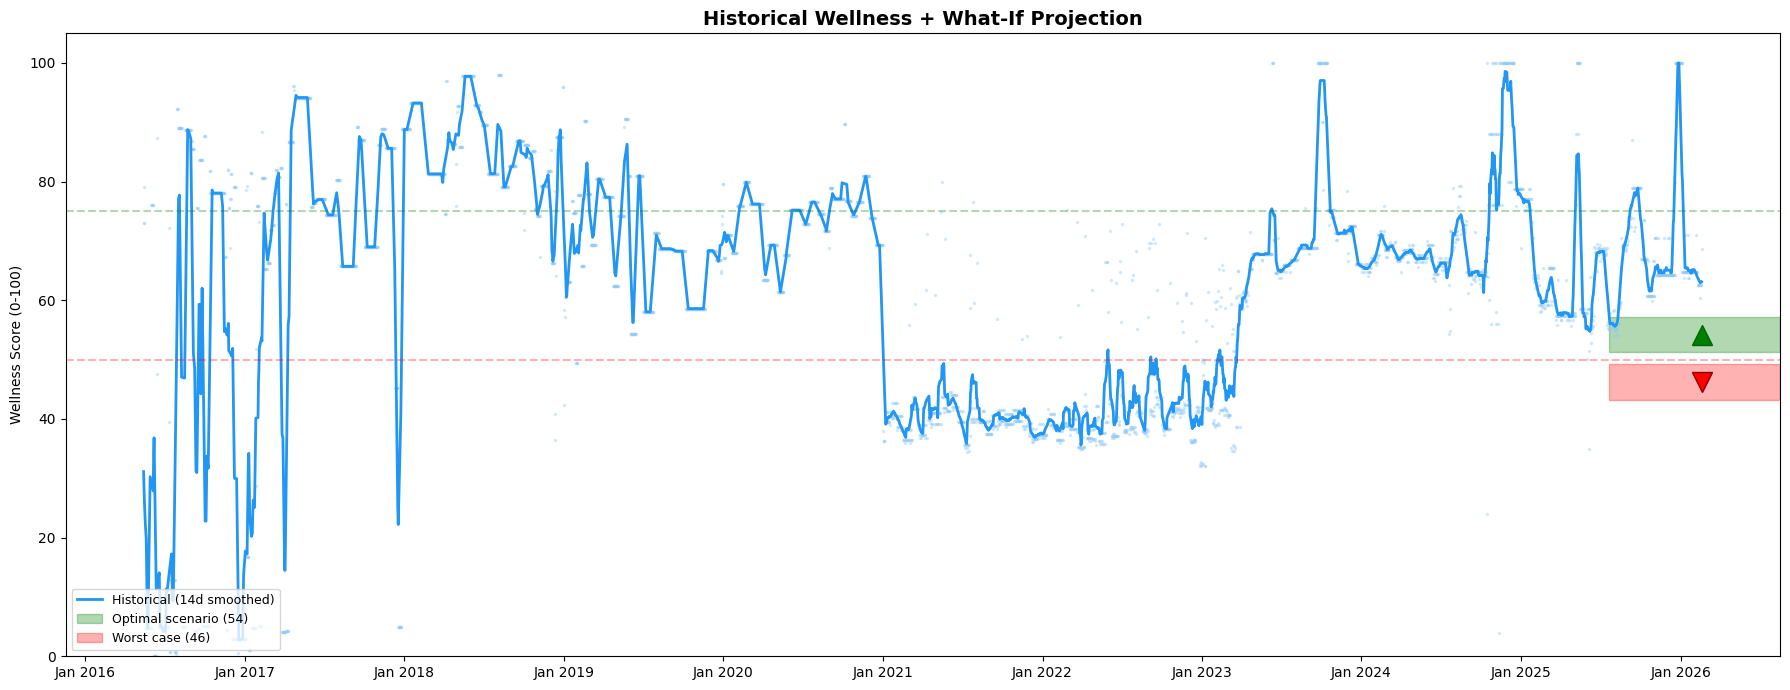

Saved: whatif_historical_overlay.png


In [14]:
# ═══════════════════════════════════════════════════════════
# CELL 12: Overlay What-If on Historical Wellness Timeline
# ═══════════════════════════════════════════════════════════

# Get historical product wellness
hist_ws = df_wellness['W_product'].dropna()
hist_smoothed = hist_ws.rolling('14D', center=True).mean()

# Create what-if projections
optimal = predict_whatif({
    'calories': 2100, 'protein': 60, 'sodium': 1500, 'potassium': 1200,
    'phosphorus': 600, 'sessions_7d': 4, 'active_days_7d': 5,
}, verbose=False)

worst = predict_whatif({
    'calories': 3500, 'protein': 20, 'sodium': 4000, 'potassium': 4000,
    'phosphorus': 1500, 'sessions_7d': 1, 'active_days_7d': 1,
}, verbose=False)

fig, ax = plt.subplots(figsize=(18, 7))

# Historical
ax.plot(hist_ws.index, hist_ws.values, '.', color='#90CAF9', alpha=0.3, markersize=3)
ax.plot(hist_smoothed.index, hist_smoothed.values, '-', color='#2196F3', linewidth=2, label='Historical (14d smoothed)')

# What-if projections as horizontal bands
future_start = hist_ws.index.max() + timedelta(days=1)
future_end = future_start + timedelta(days=30)
ax.axhspan(optimal['holistic_score'] - 3, optimal['holistic_score'] + 3,
           xmin=0.9, xmax=1.0, alpha=0.3, color='green', label=f'Optimal scenario ({optimal["holistic_score"]:.0f})')
ax.axhspan(worst['holistic_score'] - 3, worst['holistic_score'] + 3,
           xmin=0.9, xmax=1.0, alpha=0.3, color='red', label=f'Worst case ({worst["holistic_score"]:.0f})')

# Markers for current scenario
ax.plot(future_start, optimal['holistic_score'], 'g^', markersize=15, markeredgecolor='darkgreen', zorder=5)
ax.plot(future_start, worst['holistic_score'], 'rv', markersize=15, markeredgecolor='darkred', zorder=5)

ax.axhline(75, color='green', linestyle='--', alpha=0.3)
ax.axhline(50, color='red', linestyle='--', alpha=0.3)
ax.set_ylabel('Wellness Score (0-100)')
ax.set_title('Historical Wellness + What-If Projection', fontweight='bold', fontsize=14)
ax.legend(loc='lower left', fontsize=9)
ax.set_ylim(0, 105)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(FEATURES_DIR / 'whatif_historical_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: whatif_historical_overlay.png')

In [15]:
# ═══════════════════════════════════════════════════════════
# CELL 13: Export What-If Parameters for MATLAB/Simulink
# ═══════════════════════════════════════════════════════════

import scipy.io as sio

# Export everything MATLAB S08 needs
matlab_export = {
    # Feature names and baseline
    'feature_names': np.array(FEATURE_NAMES, dtype=object),
    'baseline_vector': np.array([BASELINE[f] for f in FEATURE_NAMES]),
    
    # Model coefficients (for linear approximation in Simulink)
    # Extract from GradientBoosting via feature importances
    'feature_importances': holistic_model['pipeline'].named_steps[
        list(holistic_model['pipeline'].named_steps.keys())[-1]
    ].feature_importances_ if hasattr(
        holistic_model['pipeline'].named_steps[
            list(holistic_model['pipeline'].named_steps.keys())[-1]
        ], 'feature_importances_'
    ) else np.zeros(len(FEATURE_NAMES)),
    
    # Sweep results for validation
    'sweep_potassium_values': sweep_results['potassium']['values'],
    'sweep_potassium_scores': np.array(sweep_results['potassium']['scores']),
    'sweep_sodium_values': sweep_results['sodium']['values'],
    'sweep_sodium_scores': np.array(sweep_results['sodium']['scores']),
    'sweep_blood_flow_values': sweep_results['blood_flow']['values'],
    'sweep_blood_flow_scores': np.array(sweep_results['blood_flow']['scores']),
    
    # Dialysate heatmap for Simulink validation
    'heatmap_bathK': bath_k_range,
    'heatmap_bathCa': bath_ca_range,
    'heatmap_health': heatmap_health,
    'heatmap_hypoK': heatmap_hypoK,
    'heatmap_hyperK': heatmap_hyperK,
    
    # Scenario results for cross-validation
    'scenario_names': np.array(list(scenarios.keys()), dtype=object),
    'scenario_scores': comp_df['holistic_score'].values,
    
    # Historical wellness for overlay
    'hist_wellness_dates': np.array([d.toordinal() for d in hist_ws.index]),
    'hist_wellness_values': hist_ws.values,
    
    # ESRD clinical limits
    'esrd_limits': np.array([
        [1800, 2500],      # calories
        [50, 70],          # protein (g)
        [0, 2000],         # sodium (mg)
        [0, 2000],         # potassium (mg)
        [0, 800],          # phosphorus (mg)
        [350, 450],        # blood flow (mL/min)
        [1.5, 2.5],        # bath K
        [2.0, 3.0],        # bath Ca
        [180, 270],        # session duration (min)
    ]),
    'esrd_limit_names': np.array(['calories', 'protein', 'sodium', 'potassium',
                                  'phosphorus', 'blood_flow', 'bath_k', 'bath_ca',
                                  'session_duration'], dtype=object),
}

mat_path = PROJECT_ROOT.parent / 'HEBCSL_MATLAB' / 'results' / 'S07_whatif_data.mat'
sio.savemat(str(mat_path), matlab_export)
print(f'Exported What-If data for MATLAB: {mat_path}')
print(f'  Keys: {list(matlab_export.keys())}')
print(f'  Feature importances shape: {matlab_export["feature_importances"].shape}')
print(f'  Baseline vector shape: {matlab_export["baseline_vector"].shape}')

Exported What-If data for MATLAB: /Users/woleakpose/Documents/Developer/LAFIAKALO/HEBCSL_MATLAB/results/S07_whatif_data.mat
  Keys: ['feature_names', 'baseline_vector', 'feature_importances', 'sweep_potassium_values', 'sweep_potassium_scores', 'sweep_sodium_values', 'sweep_sodium_scores', 'sweep_blood_flow_values', 'sweep_blood_flow_scores', 'heatmap_bathK', 'heatmap_bathCa', 'heatmap_health', 'heatmap_hypoK', 'heatmap_hyperK', 'scenario_names', 'scenario_scores', 'hist_wellness_dates', 'hist_wellness_values', 'esrd_limits', 'esrd_limit_names']
  Feature importances shape: (284,)
  Baseline vector shape: (284,)


In [16]:
# ═══════════════════════════════════════════════════════════
# CELL 14: Summary & MATLAB Parity Check
# ═══════════════════════════════════════════════════════════

print('═' * 70)
print('   NB07 WHAT-IF CLINICAL SIMULATOR — COMPLETE')
print('═' * 70)
print(f'''
  Models loaded:
    • Holistic health: GradientBoosting, R²={holistic_model["metrics"]["R²"]:.3f}
    • Risk models: {len(RISK_MODELS)} classifiers
    • HEBCS pathways: {len(PATHWAY_DEFS)}

  Capabilities:
    1. Single-scenario prediction (Cell 3)
    2. Multi-scenario comparison (Cell 4-5)
    3. Sensitivity sweeps — {len(SWEEP_VARS)} variables (Cell 6-7)
    4. Multi-day trajectory simulation (Cell 8)
    5. Dialysate composition 2D heatmap (Cell 9)
    6. Food item lookup & prediction (Cell 10-11)
    7. Historical overlay (Cell 12)

  Input categories:
    • Nutrition: 15 nutrients (calories, protein, Na, K, P, Ca, Fe, ...)
    • Dialysis Rx: blood flow, dialysate rate, bath composition, duration
    • Dialysis vitals: pre/post weight, BP, Kt/V
    • Medications: 5 drug categories
    • Activity: session frequency, active days, rest streak

  Outputs:
    • Holistic health score (0-100)
    • {len(RISK_MODELS)} risk probabilities
    • Sensitivity curves
    • Temporal projections

  MATLAB export:
    • {mat_path.name}
    • baseline vector, feature importances, sweep data, heatmaps
    • Ready for S08_whatif_simulink.m

  Artifacts saved:
    • whatif_scenario_comparison.png
    • whatif_sensitivity_sweeps.png
    • whatif_trajectory_14d.png
    • whatif_dialysate_heatmap.png
    • whatif_historical_overlay.png
''')

══════════════════════════════════════════════════════════════════════
   NB07 WHAT-IF CLINICAL SIMULATOR — COMPLETE
══════════════════════════════════════════════════════════════════════

  Models loaded:
    • Holistic health: GradientBoosting, R²=0.808
    • Risk models: 11 classifiers
    • HEBCS pathways: 7

  Capabilities:
    1. Single-scenario prediction (Cell 3)
    2. Multi-scenario comparison (Cell 4-5)
    3. Sensitivity sweeps — 9 variables (Cell 6-7)
    4. Multi-day trajectory simulation (Cell 8)
    5. Dialysate composition 2D heatmap (Cell 9)
    6. Food item lookup & prediction (Cell 10-11)
    7. Historical overlay (Cell 12)

  Input categories:
    • Nutrition: 15 nutrients (calories, protein, Na, K, P, Ca, Fe, ...)
    • Dialysis Rx: blood flow, dialysate rate, bath composition, duration
    • Dialysis vitals: pre/post weight, BP, Kt/V
    • Medications: 5 drug categories
    • Activity: session frequency, active days, rest streak

  Outputs:
    • Holistic health 